In [1]:
import os
import pickle
from pathlib import Path
import numpy as np

# import required module
import sys

# append the path of the
# parent directory
sys.path.append("..")
 
# import method from sibling 
# module
from data_utils import save_samples_as_cifs, save_reconstructions_as_cifs, visualize_trajectory
from utils import retrieve_artifacts_by_name


import env

# Load environment variables
env.load_envs()

# Set the cwd to the project root
PROJECT_ROOT: Path = Path(env.get_env("PROJECT_ROOT"))
assert (
    PROJECT_ROOT.exists()
), "You must configure the PROJECT_ROOT environment variable in a .env file!"

os.chdir(PROJECT_ROOT)

cwd = os.getcwd()

c:\Users\dglav\Anaconda3\envs\thesis\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [24]:
experiment_name = "sample_zdivae_small"

# artifact_files = retrieve_artifacts_by_name(experiment_name, artifact_type='dataset', project='zeogen', entity='glafk')

# for file in artifact_files:
#     if "samples" in file:
#         with open(file, "rb") as f:
#             samples = pickle.load(f)


samples_file = "reconstructions-recon_zdivae_small.pickle"

with open(f"./reconstructions/{samples_file}", "rb") as f:
    samples = pickle.load(f)

print(samples)
    # samples = samples[0]



['zd', 'zy', 'num_atoms', 'lengths', 'angles', 'frac_coords', 'atom_types', 'domains', 'norm_hoas', 'pred_hoas', 'pred_norm_hoas', 'pred_domains', 'is_traj', 'zd', 'zy', 'num_atoms', 'lengths', 'angles', 'frac_coords', 'atom_types', 'domains', 'norm_hoas', 'pred_hoas', 'pred_norm_hoas', 'pred_domains', 'is_traj', 'zd', 'zy', 'num_atoms', 'lengths', 'angles', 'frac_coords', 'atom_types', 'domains', 'norm_hoas', 'pred_hoas', 'pred_norm_hoas', 'pred_domains', 'is_traj', 'zd', 'zy', 'num_atoms', 'lengths', 'angles', 'frac_coords', 'atom_types', 'domains', 'norm_hoas', 'pred_hoas', 'pred_norm_hoas', 'pred_domains', 'is_traj']


In [23]:
print(samples.keys())
print(samples["zd"].shape)
print(samples["zy"].shape)
print(samples["num_atoms"].shape)
print(samples["lengths"].shape)
print(samples["angles"].shape)
print(samples["frac_coords"].shape)
print(samples["atom_types"].shape)
print(len(samples["domains"]))
print(len(samples["norm_hoas"]))
print(samples["pred_hoas"].shape)
print(samples["pred_norm_hoas"].shape)
print(len(samples["pred_domains"]))

AttributeError: 'str' object has no attribute 'keys'

In [20]:
print(samples["domains"][:20])
print(samples["pred_domains"][:20])

['YFI', 'MTW', 'ITW', 'MEL', 'TON', 'LTL', 'NAT', 'LTA', 'RHO', 'BEC', 'FER', 'HEU', 'DDR', 'ERI', 'FAU', 'CHA', 'MOR', 'MER', 'MFI', 'YFI']
['YFI', 'MTW', 'ITW', 'MEL', 'TON', 'LTL', 'NAT', 'LTA', 'RHO', 'BEC', 'FER', 'HEU', 'DDR', 'ERI', 'FAU', 'CHA', 'MOR', 'MER', 'MFI', 'YFI']


In [26]:
# make a dict with all zd embeddings and and predicted domains
zd_domains = []
for sample in samples:
    for zd, domain in zip(sample["zd"], sample["domains"]):
        zd_domains.extend([(zd, domain)])

print(zd_domains)
print(len(zd_domains))

[(array([-7.17922688e-01,  4.20279384e-01,  4.47157383e-01, -1.86469108e-02,
       -1.47109091e-01, -4.37638164e-02, -1.30271316e-02,  8.67379904e-02,
        1.01762867e+00, -4.89842743e-02,  5.38880080e-02,  1.14313170e-01,
        2.54342198e-01,  1.27895072e-01, -4.11118805e-01,  8.29592347e-03,
       -1.14078149e-01,  1.08527765e-01,  1.99327499e-01,  3.80268455e-01,
       -3.45504254e-01,  1.03066325e+00,  6.24905527e-01,  5.86591184e-01,
       -4.34677511e-01, -8.05314481e-02,  3.66771072e-01,  1.04329205e+00,
       -8.71114969e-01,  9.69219089e-01,  4.48198348e-01, -2.46049792e-01,
        2.56088376e-01,  2.42948264e-01, -9.72057581e-01, -3.59317869e-01,
       -5.74154854e-02,  2.72804260e-01, -5.22093177e-01, -1.15902439e-01,
        7.31892586e-01,  5.60526788e-01, -1.46197915e-01,  3.44676405e-01,
        1.70764729e-01, -8.78210515e-02, -5.36317527e-01, -7.25395232e-02,
        4.79913503e-02,  2.46259257e-01,  1.08157329e-01,  6.75766051e-01,
       -1.33557171e-01,

In [42]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
from collections import defaultdict
from sklearn.metrics import silhouette_score

# Define method for computing the t-SNE of the latent space and plotting
def plot_tsne(embeddings_list, perplexity=30.0):
    # Extract embeddings and labels
    embeddings = np.array([item[0] for item in embeddings_list])
    labels = np.array([item[1] for item in embeddings_list])

    # Compute the silhouette score
    silhouette_avg = silhouette_score(embeddings, labels)
    print(f"Silhouette score: {silhouette_avg}")

    # Perform t-SNE dimensionality reduction
    tsne = TSNE(n_components=2, random_state=42, perplexity=perplexity)
    transformed_embeddings = tsne.fit_transform(embeddings)

    # Assign unique colors to each class
    unique_labels = np.unique(labels)
    color_map = plt.cm.get_cmap("tab10", len(unique_labels))
    label_to_color = {label: color_map(i) for i, label in enumerate(unique_labels)}

    # Plot the t-SNE results
    plt.figure(figsize=(8, 6))
    for label in unique_labels:
        idxs = labels == label
        plt.scatter(
            transformed_embeddings[idxs, 0], 
            transformed_embeddings[idxs, 1], 
            color=label_to_color[label], 
            label=label, 
            alpha=0.7
        )

    plt.legend(title="Classes")
    plt.title("t-SNE Visualization of Embeddings")
    plt.xlabel("t-SNE Component 1")
    plt.ylabel("t-SNE Component 2")
    plt.show()


In [28]:
def compute_variance_per_class(embeddings_list):
    """
    Computes the variance of embeddings per class.

    :param embeddings_list: List of tuples (embedding, class_label)
    :return: Dictionary {class_label: variance_vector}
    """
    # Group embeddings by class
    class_embeddings = defaultdict(list)
    for embedding, label in embeddings_list:
        class_embeddings[label].append(embedding)

    # Convert to numpy arrays and compute variance per class
    class_variances = {}
    for label, embeddings in class_embeddings.items():
        embeddings_array = np.array(embeddings)  # Shape: (num_samples, embedding_dim)
        variance_vector = np.var(embeddings_array, axis=0)  # Variance along each dimension
        class_variances[label] = variance_vector

    return class_variances

Silhouette score: 0.3227290213108063


C:\Users\dglav\AppData\Local\Temp\ipykernel_29840\3290948103.py:23: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  color_map = plt.cm.get_cmap("tab10", len(unique_labels))


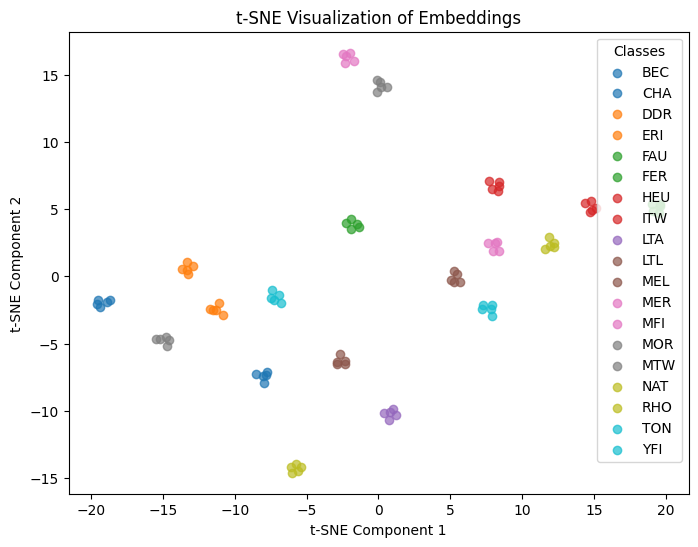

In [43]:
plot_tsne(zd_domains, perplexity=10.0)

In [30]:
variance_per_class = compute_variance_per_class(zd_domains)
for class_label, variance in variance_per_class.items():
    print(f"Variance for {class_label}: {variance}")

Variance for YFI: [0.09550385 0.10989412 0.05889722 0.01032504 0.03872168 0.00860077
 0.0540264  0.06644551 0.00660763 0.13855442 0.022387   0.00828729
 0.04838879 0.01138229 0.04683084 0.05781005 0.03033339 0.01120264
 0.02565272 0.08274897 0.01318974 0.06903104 0.02380482 0.05629852
 0.1079462  0.01674116 0.01439225 0.0067665  0.04022243 0.02697803
 0.0612865  0.01265471 0.08424008 0.03437654 0.04318576 0.03668279
 0.03728932 0.0055613  0.02146911 0.03718293 0.01119732 0.05349363
 0.01038596 0.02018561 0.02888553 0.00868027 0.01370615 0.0371279
 0.00652777 0.06258222 0.01317132 0.12304053 0.13007133 0.01014275
 0.06305259 0.02634352 0.02447902 0.07883118 0.01089558 0.01485564
 0.0447227  0.03879326 0.05373842 0.00538008 0.1002937  0.01673174
 0.02103798 0.03742057 0.06656386 0.02829663 0.05470712 0.04017808
 0.02387488 0.04716315 0.01986331 0.04652378 0.08059825 0.03118107
 0.05718719 0.05488685 0.02073419 0.01030797 0.01655474 0.02241419
 0.07240687 0.02783957 0.03406187 0.22365575 